# Model Comparison for Pairs Trading Forecasting

This notebook consolidates model evaluation outputs across the project and compares forecasting models based on **out-of-sample predictive accuracy** (holdout first, validation stability second).

## 1. Imports and Setup

In [108]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
import subprocess
import shutil
import matplotlib.pyplot as plt
plt.style.use('default')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'run_pipeline.ps1').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root containing run_pipeline.ps1 and src/')

ROOT = find_repo_root(Path.cwd().resolve())
DATA_PROCESSED = ROOT / 'data' / 'processed'
OUTPUT_SUMMARY = DATA_PROCESSED / 'model_comparison_summary.csv'

KEYWORDS = (
    'eval', 'evaluation', 'holdout', 'validation', 'results', 'metrics', 'summary',
    'forecast', 'tuning', 'prediction', 'predictions', 'signal', 'signals'
)
EXCLUDE_DIR_NAMES = {'.venv', '.git', '__pycache__', '.ipynb_checkpoints'}

KNOWN_MODELS = ['ou', 'arma', 'linear', 'xgboost', 'lstm', 'lstm_encoder_decoder']
KNOWN_SPREADS = ['ols', 'kalman']

print(f'Repo root resolved to: {ROOT}')
print(f'Processed data directory: {DATA_PROCESSED}')

Repo root resolved to: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading
Processed data directory: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed


## 2. Cache-Aware Pipeline Run (No Tuning)

In [109]:
# User-editable settings
TARGET_MODELS = ['arma', 'linear', 'xgboost', 'lstm', 'lstm_encdec', 'ou']
HORIZON = 10
TOP_K = 20
RUN_PIPELINE_IF_MISSING = True
FORCE_RERUN = False
SKIP_BACKTESTING = True
VERBOSE_PIPELINE = True

print('Section 2 configuration loaded:')
print(f'- TARGET_MODELS={TARGET_MODELS}')
print(f'- HORIZON={HORIZON}, TOP_K={TOP_K}')
print(f'- RUN_PIPELINE_IF_MISSING={RUN_PIPELINE_IF_MISSING}')
print(f'- FORCE_RERUN={FORCE_RERUN}')
print(f'- SKIP_BACKTESTING={SKIP_BACKTESTING}')
print(f'- VERBOSE_PIPELINE={VERBOSE_PIPELINE}')

Section 2 configuration loaded:
- TARGET_MODELS=['arma', 'linear', 'xgboost', 'lstm', 'lstm_encdec', 'ou']
- HORIZON=10, TOP_K=20
- RUN_PIPELINE_IF_MISSING=True
- FORCE_RERUN=False
- SKIP_BACKTESTING=True
- VERBOSE_PIPELINE=True


In [110]:
pipeline_script = ROOT / 'run_pipeline.ps1'
raw_data_dir = ROOT / 'data' / 'raw'
pair_datasets_dir = DATA_PROCESSED / 'pair_datasets'
selected_pairs_dir = DATA_PROCESSED / 'selected_pairs'

if not pipeline_script.exists():
    raise FileNotFoundError(f'Missing pipeline script: {pipeline_script}')

def list_files(patterns):
    out = []
    for pat in patterns:
        out.extend(sorted(ROOT.glob(pat)))
    # keep only files and de-duplicate
    uniq = []
    seen = set()
    for p in out:
        if p.is_file() and p not in seen:
            seen.add(p)
            uniq.append(p)
    return uniq

def find_model_artifacts(model):
    # model values are pipeline args: ou/arma/linear/xgboost/lstm/lstm_encdec
    pats = []
    if model == 'arma':
        pats = [
            'data/processed/predictions/arma_ols/*/summary_metrics*.csv',
            'data/processed/predictions/arma_kalman/*/summary_metrics*.csv',
            'data/processed/predictions/arma_ols/*/all_forecasts*.csv',
            'data/processed/predictions/arma_kalman/*/all_forecasts*.csv',
            'data/processed/predictions/arma_ols/*/predictions*.csv',
            'data/processed/predictions/arma_kalman/*/predictions*.csv',
            'data/processed/arma_tuning_outputs/arma_ols/*.csv',
            'data/processed/arma_tuning_outputs/arma_kalman/*.csv',
            'data/processed/arma_holdout_outputs/arma_ols/**/*.csv',
            'data/processed/arma_holdout_outputs/arma_kalman/**/*.csv',
        ]
    elif model == 'linear':
        pats = [
            'data/processed/linear_regression_outputs/linear_regression_ols/all_val_results.csv',
            'data/processed/linear_regression_outputs/linear_regression_ols/all_test_results.csv',
            'data/processed/linear_regression_outputs/linear_regression_ols/fold_summary.csv',
            'data/processed/linear_regression_outputs/linear_regression_ols/*/summary_metrics*.csv',
            'data/processed/linear_regression_outputs/linear_regression_ols/*/all_forecasts*.csv',
            'data/processed/linear_regression_outputs/linear_regression_ols/**/lr_metrics_*.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/all_val_results.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/all_test_results.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/fold_summary.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/*/summary_metrics*.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/*/all_forecasts*.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/**/lr_metrics_*.csv',
            'data/processed/predictions/linear_regression_ols/*/predictions.csv',
            'data/processed/predictions/linear_regression_kalman/*/predictions.csv',
        ]
    elif model == 'xgboost':
        pats = [
            'data/processed/predictions/xgboost_ols/*/metrics.csv',
            'data/processed/predictions/xgboost_kalman/*/metrics.csv',
            'data/processed/predictions/xgboost_ols/*/predictions.csv',
            'data/processed/predictions/xgboost_kalman/*/predictions.csv',
            'data/processed/predictions/xgboost_ols/best_params.csv',
            'data/processed/predictions/xgboost_kalman/best_params.csv',
            'data/processed/predictions/xgboost_ols/tuning_summary.csv',
            'data/processed/predictions/xgboost_kalman/tuning_summary.csv',
        ]
    elif model == 'lstm':
        pats = [
            'data/processed/predictions/lstm_ols/metrics_summary.csv',
            'data/processed/predictions/lstm_kalman/metrics_summary.csv',
            'data/processed/predictions/lstm_ols/tuning_results.csv',
            'data/processed/predictions/lstm_kalman/tuning_results.csv',
            'data/processed/predictions/lstm_ols/*/predictions.csv',
            'data/processed/predictions/lstm_kalman/*/predictions.csv',
        ]
    elif model == 'lstm_encdec':
        pats = [
            'data/processed/predictions/lstm_encoder_decoder_ols/metrics_summary.csv',
            'data/processed/predictions/lstm_encoder_decoder_kalman/metrics_summary.csv',
            'data/processed/predictions/lstm_encoder_decoder_ols/tuning_results.csv',
            'data/processed/predictions/lstm_encoder_decoder_kalman/tuning_results.csv',
            'data/processed/predictions/lstm_encoder_decoder_ols/*/predictions.csv',
            'data/processed/predictions/lstm_encoder_decoder_kalman/*/predictions.csv',
        ]
    elif model == 'ou':
        pats = [
            'data/processed/ou_signals_static.csv',
            'data/processed/ou_signals_kalman.csv',
        ]
    return list_files(pats)

def summarize_cache(target_models):
    rows = []
    for m in target_models:
        arts = find_model_artifacts(m)
        status = 'forced_rerun' if FORCE_RERUN else ('present' if len(arts) else 'missing')
        rows.append({
            'model': m,
            'found_artifacts_count': len(arts),
            'status': status,
            'sample_artifact_paths': '\n'.join(str(p.relative_to(ROOT)) for p in arts[:5])
        })
    return pd.DataFrame(rows)

def is_nonempty_dir(path: Path) -> bool:
    return path.exists() and any(path.rglob('*'))

def build_skip_flags():
    flags = []
    has_raw_data = is_nonempty_dir(raw_data_dir)
    has_pair_datasets = is_nonempty_dir(pair_datasets_dir)
    has_selected_pairs = is_nonempty_dir(selected_pairs_dir)

    if has_raw_data:
        flags.append('-SkipDownload')

    if has_pair_datasets:
        flags.extend(['-SkipPrep', '-SkipPairDiscovery', '-SkipPairSelection', '-SkipDatasetBuilding'])
    elif has_selected_pairs:
        flags.extend(['-SkipPrep', '-SkipPairDiscovery', '-SkipPairSelection'])

    flags.append('-SkipModelTraining')

    if SKIP_BACKTESTING:
        flags.append('-SkipBacktesting')

    return flags, has_raw_data

def run_logged(cmd, label):
    print('\n' + '=' * 100)
    print(f'RUNNING: {label}')
    print('COMMAND:', ' '.join(str(x) for x in cmd))

    if VERBOSE_PIPELINE:
        proc = subprocess.Popen(
            [str(x) for x in cmd],
            cwd=ROOT,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end='')
        ret = proc.wait()
    else:
        ret = subprocess.run([str(x) for x in cmd], cwd=ROOT).returncode

    print(f'EXIT CODE: {ret}')
    if ret != 0:
        raise RuntimeError(f'Command failed during: {label}')

def run_model_python_fallback(model, skip_flags, has_raw_data):
    py = shutil.which('python') or shutil.which('python3')
    if py is None:
        raise EnvironmentError('Python executable not found for fallback execution.')

    if not has_raw_data:
        raise RuntimeError('Raw data missing and PowerShell unavailable; cannot perform Step 0 download in fallback mode.')

    skip = set(skip_flags)

    if '-SkipPrep' not in skip:
        run_logged([py, 'prepare_data.py'], f'{model}: Step 1 Data Preparation')

    if '-SkipPairDiscovery' not in skip:
        run_logged([py, '-m', 'src.clustering.pca'], f'{model}: Step 2a PCA')
        run_logged([py, '-m', 'src.clustering.optics'], f'{model}: Step 2b OPTICS')
        run_logged([py, '-m', 'src.pairs_discovery.rank_pairs'], f'{model}: Step 2c Rank Pairs')

    if '-SkipPairSelection' not in skip:
        run_logged([py, '-m', 'src.pairs_discovery.pairs_selection', '--top_k', str(TOP_K)], f'{model}: Step 3 Pair Selection')

    if '-SkipDatasetBuilding' not in skip:
        run_logged([py, '-m', 'src.models.pair_dataset_builder'], f'{model}: Step 4 Dataset Building')

    # Step 5 intentionally skipped by design

    if model == 'ou':
        run_logged([py, '-m', 'src.models.ou'], f'{model}: Step 6 Frozen OU')
    elif model == 'arma':
        run_logged([py, '-m', 'src.models.arma', '--spread_col', 'spread_ols', '--p', '9', '--q', '8', '--horizon', str(HORIZON), '--eval_split', 'val'], f'{model}: Step 6 Frozen ARMA OLS')
        run_logged([py, '-m', 'src.models.arma', '--spread_col', 'spread_kalman', '--p', '6', '--q', '2', '--horizon', str(HORIZON), '--eval_split', 'val'], f'{model}: Step 6 Frozen ARMA Kalman')
    elif model == 'linear':
        run_logged([py, '-m', 'src.models.linear_regression'], f'{model}: Step 6 Frozen Linear')
    elif model == 'xgboost':
        run_logged([py, '-m', 'src.models.xgboost_model', '--spread_type', 'both', '--no_tune'], f'{model}: Step 6 Frozen XGBoost')
    elif model == 'lstm':
        run_logged([py, '-m', 'src.models.lstm', '--spread', 'ols', 'kalman', '--hidden', '64', '--window_size', '20', '--lr', '0.001', '--no_tune'], f'{model}: Step 6 Frozen LSTM')
    elif model == 'lstm_encdec':
        run_logged([py, '-m', 'src.models.lstm_encoder_decoder', '--spread', 'ols', 'kalman', '--hidden', '64', '--window_size', '20', '--lr', '0.001', '--no_tune'], f'{model}: Step 6 Frozen LSTM-EncDec')
    else:
        raise ValueError(f'Unsupported model in fallback: {model}')

    if '-SkipBacktesting' not in skip:
        run_logged([py, '-m', 'src.backtest.backtest_engine'], f'{model}: Step 7 Backtesting')
        run_logged([py, '-m', 'src.backtest.backtest_engine', '--holdout'], f'{model}: Step 7 Holdout Backtesting')

cache_before = summarize_cache(TARGET_MODELS)
print('Cache status before run:')
display(cache_before)

if FORCE_RERUN:
    models_to_run = list(TARGET_MODELS)
else:
    models_to_run = cache_before.loc[cache_before['status'] == 'missing', 'model'].tolist()

if not RUN_PIPELINE_IF_MISSING:
    models_to_run = []

print(f'Models selected for execution: {models_to_run}')

skip_flags, has_raw_data = build_skip_flags()
print(f'Dynamic skip flags: {skip_flags}')

ps_exe = shutil.which('pwsh') or shutil.which('powershell')

ran_models = []
if models_to_run:
    for model in models_to_run:
        if ps_exe is not None:
            cmd = [
                ps_exe, '-NoProfile', '-ExecutionPolicy', 'Bypass',
                '-File', str(pipeline_script),
                '-model', model,
                '-horizon', str(HORIZON),
                '-top_k', str(TOP_K),
            ] + skip_flags
            run_logged(cmd, f'run_pipeline.ps1 for missing model={model}')
        else:
            print('PowerShell not found. Using Python fallback for this model.')
            run_model_python_fallback(model, skip_flags, has_raw_data)

        ran_models.append(model)
else:
    print('No missing models detected (or auto-run disabled).')

cache_after = summarize_cache(TARGET_MODELS)
display(cache_after)

cached_models = cache_before.loc[(cache_before['status'] == 'present') & (~cache_before['model'].isin(ran_models)), 'model'].tolist()
still_missing = cache_after.loc[cache_after['found_artifacts_count'] == 0, 'model'].tolist()

print('\nSection 2 summary:')
print(f'- Models already cached: {cached_models}')
print(f'- Models run in this session: {ran_models}')
print(f'- Models still missing artifacts: {still_missing}')
print(f'- Backtesting skipped: {SKIP_BACKTESTING}')


Cache status before run:


,model,found_artifacts_count,status,sample_artifact_paths
0,arma,163,present,data/processed/predictions/arma_ols/2010_2012/...
1,linear,256,present,data/processed/linear_regression_outputs/linea...
2,xgboost,24,present,data/processed/predictions/xgboost_ols/2010_20...
3,lstm,14,present,data/processed/predictions/lstm_ols/metrics_su...
4,lstm_encdec,14,present,data/processed/predictions/lstm_encoder_decode...
5,ou,2,present,data/processed/ou_signals_static.csv\ndata/pro...


Models selected for execution: []
Dynamic skip flags: ['-SkipDownload', '-SkipPrep', '-SkipPairDiscovery', '-SkipPairSelection', '-SkipDatasetBuilding', '-SkipModelTraining', '-SkipBacktesting']
No missing models detected (or auto-run disabled).


,model,found_artifacts_count,status,sample_artifact_paths
0,arma,163,present,data/processed/predictions/arma_ols/2010_2012/...
1,linear,256,present,data/processed/linear_regression_outputs/linea...
2,xgboost,24,present,data/processed/predictions/xgboost_ols/2010_20...
3,lstm,14,present,data/processed/predictions/lstm_ols/metrics_su...
4,lstm_encdec,14,present,data/processed/predictions/lstm_encoder_decode...
5,ou,2,present,data/processed/ou_signals_static.csv\ndata/pro...



Section 2 summary:
- Models already cached: ['arma', 'linear', 'xgboost', 'lstm', 'lstm_encdec', 'ou']
- Models run in this session: []
- Models still missing artifacts: []
- Backtesting skipped: True


## 3. Locate and Load Result Files

In [111]:
def should_exclude(path: Path) -> bool:
    return any(part in EXCLUDE_DIR_NAMES for part in path.parts)

def is_likely_result_file(path: Path) -> bool:
    if path.suffix.lower() not in {'.csv', '.json'}:
        return False
    text = path.as_posix().lower()
    return any(k in text for k in KEYWORDS)

def source_priority(path: Path) -> int:
    s = path.as_posix().lower()
    metric_keywords = ('metrics', 'summary', 'results', 'forecast', 'holdout', 'validation', 'eval')
    prediction_keywords = ('prediction', 'predictions')
    signal_keywords = ('signal', 'signals')
    if any(k in s for k in metric_keywords):
        return 0
    if any(k in s for k in prediction_keywords):
        return 1
    if any(k in s for k in signal_keywords):
        return 2
    return 3

candidate_files = []
for p in ROOT.rglob('*'):
    if not p.is_file():
        continue
    if should_exclude(p):
        continue
    if is_likely_result_file(p):
        candidate_files.append(p)

candidate_files = sorted(candidate_files, key=lambda p: (source_priority(p), str(p).lower()))

# Focus on likely model outputs first
priority_files = [p for p in candidate_files if 'data/processed' in p.as_posix().lower()]
other_files = [p for p in candidate_files if p not in priority_files]

print(f'Total candidate files found: {len(candidate_files)}')
print(f'  In data/processed: {len(priority_files)}')
print(f'  Outside data/processed: {len(other_files)}')

candidate_df = pd.DataFrame({
    'path': [str(p.relative_to(ROOT)) for p in candidate_files],
    'suffix': [p.suffix.lower() for p in candidate_files],
    'priority': [source_priority(p) for p in candidate_files],
}).sort_values(['priority', 'path']).reset_index(drop=True)

candidate_df.head(80)

Total candidate files found: 967
  In data/processed: 962
  Outside data/processed: 5


,path,suffix,priority
0,data/clustering/2010_2012/optics_summary.csv,.csv,0
1,data/clustering/2011_2013/optics_summary.csv,.csv,0
2,data/clustering/2012_2014/optics_summary.csv,.csv,0
3,data/clustering/2013_2015/optics_summary.csv,.csv,0
4,data/clustering/2014_2016/optics_summary.csv,.csv,0
...,...,...,...
75,data/processed/arma_holdout_outputs/arma_ols/2...,.csv,0
76,data/processed/arma_holdout_outputs/arma_ols/2...,.csv,0
77,data/processed/arma_holdout_outputs/arma_ols/2...,.csv,0
78,data/processed/arma_holdout_outputs/arma_ols/2...,.csv,0


## 4. Inspect Schemas and Infer Metadata

In [112]:
def infer_model_from_path(path: Path) -> str:
    s = path.as_posix().lower()
    if 'lstm_encoder_decoder' in s or 'encdec' in s:
        return 'lstm_encoder_decoder'
    if 'xgboost' in s:
        return 'xgboost'
    if 'lstm' in s:
        return 'lstm'
    if 'arma' in s:
        return 'arma'
    if re.search(r'(^|[_/\-])ou([_/\-]|$)', s):
        return 'ou'
    if 'linear' in s:
        return 'linear'
    return 'unknown'

def infer_spread_from_path(path: Path) -> str:
    s = path.as_posix().lower()
    if 'kalman' in s:
        return 'kalman'
    if 'ols' in s:
        return 'ols'
    return 'unknown'

def infer_horizon_from_path(path: Path):
    s = path.as_posix().lower()
    m = re.search(r'horizon[_=\-]?(\d+)', s)
    if m:
        return int(m.group(1))
    return np.nan

def infer_split_from_text(text: str) -> str:
    t = str(text).lower()
    if any(x in t for x in ['holdout', 'test', 'out_of_sample', 'oos']):
        return 'holdout'
    if any(x in t for x in ['val', 'validation']):
        return 'validation'
    return 'unknown'

schema_rows = []
for p in priority_files:
    rel = p.relative_to(ROOT)
    row = {
        'path': str(rel),
        'model_guess': infer_model_from_path(p),
        'spread_guess': infer_spread_from_path(p),
        'horizon_guess': infer_horizon_from_path(p),
        'readable': False,
        'n_rows': np.nan,
        'columns': None,
        'error': None,
    }
    try:
        if p.suffix.lower() == '.csv':
            df = pd.read_csv(p)
        elif p.suffix.lower() == '.json':
            with open(p, 'r') as f:
                obj = json.load(f)
            df = pd.json_normalize(obj) if isinstance(obj, (list, dict)) else pd.DataFrame()
        else:
            raise ValueError('Unsupported suffix')
        row['readable'] = True
        row['n_rows'] = len(df)
        row['columns'] = ', '.join(df.columns.astype(str).tolist())
    except Exception as e:
        row['error'] = str(e)
    schema_rows.append(row)

schema_df = pd.DataFrame(schema_rows).sort_values('path').reset_index(drop=True)
print(f'Readable files in data/processed candidates: {schema_df.readable.sum()} / {len(schema_df)}')
schema_df.head(60)

Readable files in data/processed candidates: 962 / 962


,path,model_guess,spread_guess,horizon_guess,readable,n_rows,columns,error
0,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,208,"forecast_origin_date, target_date, current_spr...",None
1,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,1,"pair, window_label, eval_split, spread_col, se...",None
2,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,208,"forecast_origin_date, target_date, current_spr...",None
3,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,1,"pair, window_label, eval_split, spread_col, se...",None
4,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,208,"forecast_origin_date, target_date, current_spr...",None
5,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,1,"pair, window_label, eval_split, spread_col, se...",None
6,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,208,"forecast_origin_date, target_date, current_spr...",None
7,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,1,"pair, window_label, eval_split, spread_col, se...",None
8,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,208,"forecast_origin_date, target_date, current_spr...",None
9,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,1,"pair, window_label, eval_split, spread_col, se...",None


## 5. Standardize Results Into a Unified Format

In [113]:
STANDARDIZED_COLS = [
  'model',
  'spread_type',
  'dataset_split',
  'horizon',
  'window_label',
  'metric_source',
  'source_kind',
  'aggregation_level',
  'is_tuning',
  'mse',
  'rmse',
  'mae',
  'mse_comparable',
  'notes'
]

DEFAULT_HORIZON_MODELS = {'arma', 'linear', 'xgboost', 'lstm', 'lstm_encdec'}

def to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def first_existing(row, keys):
    for k in keys:
        if k in row and pd.notna(row[k]):
            return row[k]
    return np.nan

def normalize_spread(raw):
    if pd.isna(raw):
        return 'unknown'
    s = str(raw).lower()
    if 'kalman' in s:
        return 'kalman'
    if 'ols' in s:
        return 'ols'
    return s

def infer_window_from_path(path: Path):
    m = re.search(r'(20\d{2}_20\d{2})', path.as_posix())
    return m.group(1) if m else np.nan

def normalize_split(raw, fallback_path: Path):
    split = infer_split_from_text(raw)
    if split != 'unknown':
        return split
    return infer_split_from_text(fallback_path.as_posix())

def append_row(rows, **kwargs):
    row = {c: np.nan for c in STANDARDIZED_COLS}
    row.update(kwargs)
    rows.append(row)

def normalize_model_name(raw):
    s = str(raw).lower()
    if 'encoder_decoder' in s or s == 'lstm_encoder_decoder':
        return 'lstm_encdec'
    return s

standard_rows = []
used_files = []
skipped_files = []

# ARMA: detect where summary_metrics_val exists so summary_metrics.csv fallback can be controlled
arma_val_windows = set()
for pth in priority_files:
    s = pth.as_posix().lower()
    if 'data/processed/predictions/arma_' in s and pth.name == 'summary_metrics_val.csv':
        arma_val_windows.add((infer_spread_from_path(pth), infer_window_from_path(pth)))

for pth in priority_files:
    src = str(pth.relative_to(ROOT))
    src_lower = src.lower()

    if pth.suffix.lower() != '.csv':
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: non-csv'})
        continue

    # OU exclusion
    if pth.name in {'ou_signals_static.csv', 'ou_signals_kalman.csv'}:
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: OU artifacts are signal outputs, not supervised error metrics'})
        continue

    try:
        df = pd.read_csv(pth)
    except Exception as e:
        skipped_files.append({'path': src, 'reason': f'excluded_noncomparable: read_failed ({e})'})
        continue

    if df.empty:
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: empty file'})
        continue

    model_guess = normalize_model_name(infer_model_from_path(pth))
    spread_guess = infer_spread_from_path(pth)
    window_guess = infer_window_from_path(pth)
    file_used = False

    # ---------------- ARMA ----------------
    if 'arma_holdout_outputs' in src_lower and pth.name == 'holdout_summary.csv':
        for _, r in df.iterrows():
            append_row(
                standard_rows,
                model='arma',
                spread_type=normalize_spread(first_existing(r, ['spread_col', spread_guess])),
                dataset_split='holdout',
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=first_existing(r, ['holdout_window', 'window_label']),
                metric_source=src,
                source_kind='final_metrics',
                aggregation_level='model_aggregate',
                is_tuning=False,
                mse=to_float(first_existing(r, ['mean_mse', 'mse'])),
                rmse=to_float(first_existing(r, ['mean_rmse', 'rmse'])),
                mae=to_float(first_existing(r, ['mean_mae', 'mae'])),
                notes='ARMA holdout_summary.csv'
            )
        file_used = True

    elif 'predictions/arma_' in src_lower and pth.name in {'summary_metrics_val.csv', 'summary_metrics.csv'}:
        # summary_metrics.csv only if *_val absent for same spread/window
        if pth.name == 'summary_metrics.csv' and (spread_guess, window_guess) in arma_val_windows:
            skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: summary_metrics_val.csv exists for same ARMA spread/window'})
            continue

        for _, r in df.iterrows():
            append_row(
                standard_rows,
                model='arma',
                spread_type=normalize_spread(first_existing(r, ['spread_col', spread_guess])),
                dataset_split='validation',
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=first_existing(r, ['window_label', window_guess]),
                metric_source=src,
                source_kind='final_metrics',
                aggregation_level='pair_level',
                is_tuning=False,
                mse=to_float(first_existing(r, ['mse', 'mean_mse'])),
                rmse=to_float(first_existing(r, ['rmse', 'mean_rmse'])),
                mae=to_float(first_existing(r, ['mae', 'mean_mae'])),
                notes=f'ARMA {pth.name} treated as pair_level; aggregated in notebook'
            )
        file_used = True

    elif 'arma_tuning_outputs' in src_lower and pth.name == 'selected_global_params.csv':
        for _, r in df.iterrows():
            append_row(
                standard_rows,
                model='arma',
                spread_type=normalize_spread(first_existing(r, ['spread_col', spread_guess])),
                dataset_split='validation',
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=np.nan,
                metric_source=src,
                source_kind='tuning_summary',
                aggregation_level='model_aggregate',
                is_tuning=True,
                mse=to_float(first_existing(r, ['mean_val_mse', 'avg_val_mse'])),
                rmse=np.nan,
                mae=np.nan,
                notes='ARMA selected_global_params.csv tuning summary'
            )
        file_used = True

    elif ('arma_holdout_outputs' in src_lower and pth.name == 'final_holdout_results.csv') or \
         ('arma_tuning_outputs' in src_lower and pth.name == 'all_validation_results.csv') or \
         ('predictions/arma_' in src_lower and ('all_forecasts' in pth.name or pth.name.startswith('predictions'))):
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: pair-level/candidate-grid/forecast detail not used for final ranking'})
        continue

    # ---------------- Linear ----------------
    elif 'linear_regression_outputs' in src_lower and pth.name in {'all_val_results.csv', 'all_test_results.csv'}:
        split = 'validation' if pth.name == 'all_val_results.csv' else 'holdout'
        for _, r in df.iterrows():
            append_row(
                standard_rows,
                model='linear',
                spread_type=normalize_spread(first_existing(r, ['spread_col', 'target_col', spread_guess])),
                dataset_split=split,
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=first_existing(r, ['window_label']),
                metric_source=src,
                source_kind='final_metrics',
                aggregation_level='pair_level',
                is_tuning=False,
                mse=to_float(first_existing(r, ['mse', 'mean_mse'])),
                rmse=to_float(first_existing(r, ['rmse', 'mean_rmse'])),
                mae=to_float(first_existing(r, ['mae', 'mean_mae'])),
                notes=f'Linear {pth.name} treated as pair_level; aggregated in notebook'
            )
        file_used = True

    elif 'linear_regression_outputs' in src_lower and pth.name == 'fold_summary.csv':
        for _, r in df.iterrows():
            append_row(
                standard_rows,
                model='linear',
                spread_type=spread_guess,
                dataset_split='validation',
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=np.nan,
                metric_source=src,
                source_kind='tuning_summary',
                aggregation_level='model_aggregate',
                is_tuning=True,
                mse=to_float(first_existing(r, ['avg_val_mse', 'mean_val_mse', 'val_mse'])),
                rmse=np.nan,
                mae=np.nan,
                notes='Linear fold_summary.csv tuning summary'
            )
        file_used = True

    elif 'linear_regression_outputs' in src_lower and 'lr_metrics_' in pth.name:
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: pair-level lr_metrics not used in final ranking'})
        continue

    # ---------------- XGBoost ----------------
    elif 'predictions/xgboost_' in src_lower and pth.name == 'metrics.csv':
        for _, r in df.iterrows():
            append_row(
                standard_rows,
                model='xgboost',
                spread_type=normalize_spread(first_existing(r, ['spread_type', spread_guess])),
                dataset_split=normalize_split(first_existing(r, ['split']), pth),
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=first_existing(r, ['window_label', window_guess]),
                metric_source=src,
                source_kind='final_metrics',
                aggregation_level='window_aggregate',
                is_tuning=False,
                mse=to_float(first_existing(r, ['test_mse', 'mse'])),
                rmse=to_float(first_existing(r, ['test_rmse', 'rmse'])),
                mae=to_float(first_existing(r, ['test_mae', 'mae'])),
                notes='XGBoost metrics.csv'
            )
        file_used = True

    elif 'predictions/xgboost_' in src_lower and pth.name == 'tuning_summary.csv':
        for _, r in df.iterrows():
            append_row(
                standard_rows,
                model='xgboost',
                spread_type=spread_guess,
                dataset_split='validation',
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=first_existing(r, ['window_label', window_guess]),
                metric_source=src,
                source_kind='tuning_summary',
                aggregation_level='model_aggregate',
                is_tuning=True,
                mse=to_float(first_existing(r, ['val_mse', 'avg_val_mse'])),
                rmse=np.nan,
                mae=np.nan,
                notes='XGBoost tuning_summary.csv'
            )
        file_used = True

    elif 'predictions/xgboost_' in src_lower and pth.name == 'best_params.csv':
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: best_params has no direct error metric row for ranking'})
        continue

    # ---------------- LSTM / LSTM EncDec ----------------
    elif pth.name == 'metrics_summary.csv' and ('predictions/lstm' in src_lower):
        model_name = 'lstm_encdec' if 'encoder_decoder' in src_lower else 'lstm'
        for _, r in df.iterrows():
            if 'is_holdout' in df.columns and pd.notna(r.get('is_holdout')):
                split = 'holdout' if bool(r['is_holdout']) else 'validation'
            else:
                split = 'validation'
            append_row(
                standard_rows,
                model=model_name,
                spread_type=spread_guess,
                dataset_split=split,
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=first_existing(r, ['window', 'window_label', window_guess]),
                metric_source=src,
                source_kind='final_metrics',
                aggregation_level='model_aggregate',
                is_tuning=False,
                mse=to_float(first_existing(r, ['mse'])),
                rmse=to_float(first_existing(r, ['rmse'])),
                mae=to_float(first_existing(r, ['mae'])),
                notes='LSTM-family metrics_summary.csv'
            )
        file_used = True

    elif pth.name == 'tuning_results.csv' and ('predictions/lstm' in src_lower):
        model_name = 'lstm_encdec' if 'encoder_decoder' in src_lower else 'lstm'
        for _, r in df.iterrows():
            append_row(
                standard_rows,
                model=model_name,
                spread_type=spread_guess,
                dataset_split='validation',
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=np.nan,
                metric_source=src,
                source_kind='tuning_summary',
                aggregation_level='model_aggregate',
                is_tuning=True,
                mse=to_float(first_existing(r, ['avg_val_mse'])),
                rmse=np.nan,
                mae=np.nan,
                notes='LSTM-family tuning_results.csv'
            )
        file_used = True

    if file_used:
        used_files.append({'path': src, 'n_rows_loaded': len(df)})
    else:
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: not mapped into strict final/tuning schema'})

standardized = pd.DataFrame(standard_rows, columns=STANDARDIZED_COLS)

# Horizon cleanup
if not standardized.empty:
    standardized['model'] = standardized['model'].astype(str).str.lower().map(normalize_model_name)
    standardized['horizon'] = pd.to_numeric(standardized['horizon'], errors='coerce')
    mask_default_h = standardized['horizon'].isna() & standardized['model'].isin(DEFAULT_HORIZON_MODELS)
    standardized.loc[mask_default_h, 'horizon'] = 10.0

# Comparable metric derivation
standardized['mse'] = pd.to_numeric(standardized['mse'], errors='coerce')
standardized['rmse'] = pd.to_numeric(standardized['rmse'], errors='coerce')
standardized['mae'] = pd.to_numeric(standardized['mae'], errors='coerce')
standardized['mse_comparable'] = standardized['mse']
standardized.loc[standardized['mse_comparable'].isna() & standardized['rmse'].notna(), 'mse_comparable'] = standardized['rmse'] ** 2

# Fallback (last resort): derive from predictions only when exact model/spread/split has no final metric rows

def has_final_metric_for(model, spread, split):
    if standardized.empty:
        return False
    m = standardized['model'].astype(str).str.lower().eq(str(model).lower())
    s = standardized['spread_type'].astype(str).str.lower().eq(str(spread).lower())
    d = standardized['dataset_split'].astype(str).str.lower().eq(str(split).lower())
    final = standardized['source_kind'].eq('final_metrics') & (standardized['is_tuning'] == False)
    return bool((m & s & d & final & standardized['mse_comparable'].notna()).any())

def infer_model_spread_from_pred_path(pred_path: Path):
    s = pred_path.as_posix().lower()
    if 'lstm_encoder_decoder' in s:
        model = 'lstm_encdec'
    elif 'lstm' in s:
        model = 'lstm'
    elif 'xgboost' in s:
        model = 'xgboost'
    elif 'linear_regression' in s:
        model = 'linear'
    elif 'arma' in s:
        model = 'arma'
    else:
        model = 'unknown'
    spread = 'kalman' if 'kalman' in s else ('ols' if 'ols' in s else 'unknown')
    return model, spread

fallback_rows = []
prediction_files = [f for f in priority_files if f.name == 'predictions.csv' and 'data/processed/predictions/' in f.as_posix().lower()]

for pred_path in prediction_files:
    model_name, spread_name = infer_model_spread_from_pred_path(pred_path)
    if model_name not in {'xgboost', 'lstm', 'lstm_encdec', 'linear'}:
        continue

    window = infer_window_from_path(pred_path)
    if pd.isna(window):
        continue

    target_col = 'label_continuous_10d' if spread_name == 'ols' else ('label_kalman_10d' if spread_name == 'kalman' else None)
    if target_col is None:
        continue

    try:
        pred_df = pd.read_csv(pred_path)
    except Exception as e:
        skipped_files.append({'path': str(pred_path.relative_to(ROOT)), 'reason': f'fallback_failed: {e}'})
        continue

    if not {'Date', 'pair'}.issubset(set(pred_df.columns)):
        continue

    pred_col = None
    for c in ['predicted_spread_change', 'predicted_change', 'predicted']:
        if c in pred_df.columns:
            pred_col = c
            break
    if pred_col is None:
        continue

    pred_df = pred_df[['Date', 'pair', pred_col]].copy()
    pred_df['Date'] = pd.to_datetime(pred_df['Date'], errors='coerce')
    pred_df['pair'] = pred_df['pair'].astype(str)

    for split_name, ds_path in [
        ('validation', DATA_PROCESSED / 'pair_datasets' / str(window) / 'val_pair_dataset.csv'),
        ('holdout', DATA_PROCESSED / 'pair_datasets' / str(window) / 'test_pair_dataset.csv'),
    ]:
        if has_final_metric_for(model_name, spread_name, split_name):
            continue
        if not ds_path.exists():
            continue

        ds = pd.read_csv(ds_path)
        if not {'Date', 'pair', target_col}.issubset(set(ds.columns)):
            continue

        ds = ds[['Date', 'pair', target_col]].copy()
        ds['Date'] = pd.to_datetime(ds['Date'], errors='coerce')
        ds['pair'] = ds['pair'].astype(str)

        merged = pred_df.merge(ds, on=['Date', 'pair'], how='inner').dropna(subset=[pred_col, target_col])
        if merged.empty:
            continue

        err = merged[pred_col] - merged[target_col]
        mse = float(np.mean(np.square(err)))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(err)))

        append_row(
            fallback_rows,
            model=model_name,
            spread_type=spread_name,
            dataset_split=split_name,
            horizon=10.0,
            window_label=window,
            metric_source=str(pred_path.relative_to(ROOT)),
            source_kind='fallback_derived',
            aggregation_level='window_aggregate',
            is_tuning=False,
            mse=mse,
            rmse=rmse,
            mae=mae,
            mse_comparable=mse,
            notes=f'Fallback derived from predictions.csv + {ds_path.name}'
        )

if fallback_rows:
    fb = pd.DataFrame(fallback_rows, columns=STANDARDIZED_COLS)
    standardized = pd.concat([standardized, fb], ignore_index=True)

# recompute mse_comparable after fallback concat
standardized['mse'] = pd.to_numeric(standardized['mse'], errors='coerce')
standardized['rmse'] = pd.to_numeric(standardized['rmse'], errors='coerce')
standardized['mse_comparable'] = pd.to_numeric(standardized['mse_comparable'], errors='coerce')
standardized.loc[standardized['mse_comparable'].isna() & standardized['mse'].notna(), 'mse_comparable'] = standardized['mse']
standardized.loc[standardized['mse_comparable'].isna() & standardized['rmse'].notna(), 'mse_comparable'] = standardized['rmse'] ** 2

used_files_df = pd.DataFrame(used_files).drop_duplicates().sort_values('path').reset_index(drop=True) if used_files else pd.DataFrame(columns=['path','n_rows_loaded'])
skipped_files_df = pd.DataFrame(skipped_files).sort_values('path').reset_index(drop=True) if skipped_files else pd.DataFrame(columns=['path','reason'])

print(f'Total standardized rows: {len(standardized)}')
print('\nDiagnostics 1: standardized counts by model/dataset_split/source_kind/aggregation_level')
if not standardized.empty:
    display(
        standardized.groupby(['model','dataset_split','source_kind','aggregation_level'], dropna=False)
        .size().reset_index(name='rows').sort_values('rows', ascending=False)
    )

print(f'Number of tuning rows: {int(standardized["is_tuning"].fillna(False).sum()) if len(standardized) else 0}')
print(f'Number of skipped files: {len(skipped_files_df)}')
print('\nSkipped files audit (first 40):')
display(skipped_files_df.head(40))

standardized.head(20)


Total standardized rows: 566

Diagnostics 1: standardized counts by model/dataset_split/source_kind/aggregation_level


,model,dataset_split,source_kind,aggregation_level,rows
4,linear,validation,final_metrics,pair_level,160
14,xgboost,validation,tuning_summary,model_aggregate,144
1,arma,validation,final_metrics,pair_level,140
3,linear,holdout,final_metrics,pair_level,40
8,lstm,validation,tuning_summary,model_aggregate,16
11,lstm_encdec,validation,tuning_summary,model_aggregate,16
12,xgboost,holdout,final_metrics,window_aggregate,10
5,linear,validation,tuning_summary,model_aggregate,8
7,lstm,validation,final_metrics,model_aggregate,8
10,lstm_encdec,validation,final_metrics,model_aggregate,8


Number of tuning rows: 186
Number of skipped files: 925

Skipped files audit (first 40):


,path,reason
0,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
1,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
2,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
3,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
4,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
5,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
6,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
7,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
8,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
9,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...


,model,spread_type,dataset_split,horizon,window_label,metric_source,source_kind,aggregation_level,is_tuning,mse,rmse,mae,mse_comparable,notes
0,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,model_aggregate,False,0.000821,0.025613,0.020028,0.000821,ARMA holdout_summary.csv
1,arma,ols,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_ols/h...,final_metrics,model_aggregate,False,1150.814782,7.620430,0.560990,1150.814782,ARMA holdout_summary.csv
2,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000116,0.010772,0.008758,0.000116,Linear all_test_results.csv treated as pair_le...
3,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000197,0.014040,0.010038,0.000197,Linear all_test_results.csv treated as pair_le...
4,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000227,0.015059,0.009774,0.000227,Linear all_test_results.csv treated as pair_le...
5,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000362,0.019029,0.013016,0.000362,Linear all_test_results.csv treated as pair_le...
6,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000416,0.020401,0.015694,0.000416,Linear all_test_results.csv treated as pair_le...
7,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000456,0.021353,0.017397,0.000456,Linear all_test_results.csv treated as pair_le...
8,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000640,0.025290,0.018320,0.000640,Linear all_test_results.csv treated as pair_le...
9,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000650,0.025495,0.021796,0.000650,Linear all_test_results.csv treated as pair_le...


In [114]:
print('Used files (transparent provenance):')
display(used_files_df)

print('Skipped files and reasons:')
display(skipped_files_df.head(200))

Used files (transparent provenance):


,path,n_rows_loaded
0,data/processed/arma_holdout_outputs/arma_kalma...,1
1,data/processed/arma_holdout_outputs/arma_ols/h...,1
2,data/processed/arma_tuning_outputs/arma_kalman...,1
3,data/processed/arma_tuning_outputs/arma_ols/se...,1
4,data/processed/linear_regression_outputs/linea...,20
5,data/processed/linear_regression_outputs/linea...,80
6,data/processed/linear_regression_outputs/linea...,4
7,data/processed/linear_regression_outputs/linea...,20
8,data/processed/linear_regression_outputs/linea...,80
9,data/processed/linear_regression_outputs/linea...,4


Skipped files and reasons:


,path,reason
0,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
1,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
2,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
3,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
4,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: not mapped into strict...
...,...,...
195,data/processed/linear_regression_outputs/linea...,excluded_noncomparable: pair-level lr_metrics ...
196,data/processed/linear_regression_outputs/linea...,excluded_noncomparable: not mapped into strict...
197,data/processed/linear_regression_outputs/linea...,excluded_noncomparable: pair-level lr_metrics ...
198,data/processed/linear_regression_outputs/linea...,excluded_noncomparable: not mapped into strict...


## 6. Master Comparison Tables

**Primary ranking rule:** use `mse_comparable` for supervised holdout ranking (single metric across models).

In [115]:
# Build final metric rows only (exclude tuning)
full_table = standardized.copy()
for col in ['model','spread_type','dataset_split','horizon','window_label','metric_source','source_kind','aggregation_level','is_tuning','mse','rmse','mae','mse_comparable','notes']:
    if col not in full_table.columns:
        full_table[col] = np.nan

full_table['is_tuning'] = full_table['is_tuning'].fillna(False).astype(bool)
for col in ['mse','rmse','mae','mse_comparable','horizon']:
    full_table[col] = pd.to_numeric(full_table[col], errors='coerce')
full_table['model'] = full_table['model'].astype(str).str.lower()
full_table['spread_type'] = full_table['spread_type'].astype(str).str.lower()
full_table['dataset_split'] = full_table['dataset_split'].astype(str).str.lower()

if full_table['mse_comparable'].isna().all():
    full_table['mse_comparable'] = full_table['mse']
    full_table.loc[full_table['mse_comparable'].isna() & full_table['rmse'].notna(), 'mse_comparable'] = full_table['rmse'] ** 2

final_metric_rows = full_table[
    (full_table['is_tuning'] == False) &
    (full_table['source_kind'].isin(['final_metrics', 'fallback_derived']))
].copy()

validation_raw = final_metric_rows[final_metric_rows['dataset_split'] == 'validation'].copy()
holdout_raw = final_metric_rows[final_metric_rows['dataset_split'] == 'holdout'].copy()

# For compatibility with section 7 plots
holdout_rows = holdout_raw.copy()

def aggregate_final_metrics(df):
    if df.empty:
        return pd.DataFrame(columns=['model','spread_type','dataset_split','horizon','n_rows','mse_comparable_mean','mse_comparable_std','mse_mean','rmse_mean','mae_mean','aggregation_level'])

    work = df.copy()

    # Step 1: pair-level -> window-level
    pair_rows = work[work['aggregation_level'] == 'pair_level'].copy()
    non_pair_rows = work[work['aggregation_level'] != 'pair_level'].copy()

    window_from_pair = pd.DataFrame(columns=work.columns)
    if not pair_rows.empty:
        grp = pair_rows.groupby(['model','spread_type','dataset_split','window_label','horizon'], dropna=False, as_index=False)
        window_from_pair = grp.agg(
            mse=('mse', 'mean'),
            rmse=('rmse', 'mean'),
            mae=('mae', 'mean'),
            mse_comparable=('mse_comparable', 'mean'),
            n_pair_rows=('mse_comparable', 'size')
        )
        window_from_pair['metric_source'] = 'aggregated_pair_level_in_notebook'
        window_from_pair['source_kind'] = 'final_metrics'
        window_from_pair['aggregation_level'] = 'window_aggregate'
        window_from_pair['is_tuning'] = False
        window_from_pair['notes'] = 'pair_level -> window_aggregate mean'

    stage1 = pd.concat([non_pair_rows, window_from_pair], ignore_index=True, sort=False)

    # Step 2: window/model-level -> final model-level per model/spread/split/horizon
    grp2 = stage1.groupby(['model','spread_type','dataset_split','horizon'], dropna=False, as_index=False)
    final = grp2.agg(
        n_rows=('mse_comparable', 'size'),
        mse_comparable_mean=('mse_comparable', 'mean'),
        mse_comparable_std=('mse_comparable', 'std'),
        mse_mean=('mse', 'mean'),
        rmse_mean=('rmse', 'mean'),
        mae_mean=('mae', 'mean')
    )
    final['aggregation_level'] = 'model_aggregate'
    return final

holdout_final = aggregate_final_metrics(holdout_raw)
validation_final = aggregate_final_metrics(validation_raw)

# Holdout ranking (single metric)
holdout_ranking = holdout_final.rename(columns={
    'mse_comparable_mean': 'holdout_mse_mean',
    'mse_comparable_std': 'holdout_mse_std'
}).copy()
holdout_ranking = holdout_ranking[['model','spread_type','horizon','n_rows','holdout_mse_mean','holdout_mse_std']]
holdout_ranking = holdout_ranking.sort_values('holdout_mse_mean', ascending=True, na_position='last').reset_index(drop=True)
holdout_ranking['holdout_rank'] = np.arange(1, len(holdout_ranking) + 1)

# Validation ranking (single metric family: mse_comparable)
validation_ranking = validation_final.rename(columns={
    'mse_comparable_mean': 'validation_mse_mean',
    'mse_comparable_std': 'validation_mse_std'
}).copy()
validation_ranking = validation_ranking[['model','spread_type','horizon','n_rows','validation_mse_mean','validation_mse_std']]
validation_ranking = validation_ranking.sort_values('validation_mse_mean', ascending=True, na_position='last').reset_index(drop=True)
validation_ranking['validation_rank'] = np.arange(1, len(validation_ranking) + 1)

# Tuning summary (separate)
tuning_rows = full_table[full_table['is_tuning'] == True].copy()
tuning_summary = (
    tuning_rows
    .groupby(['model','spread_type','horizon'], dropna=False, as_index=False)
    .agg(
        tuning_rows=('mse_comparable', 'size'),
        tuning_avg_val_mse_mean=('mse_comparable', 'mean'),
        tuning_avg_val_mse_std=('mse_comparable', 'std')
    )
    .sort_values('tuning_avg_val_mse_mean', ascending=True, na_position='last')
    .reset_index(drop=True)
)

# Compatibility aliases for downstream cells
holdout_ranking['metric_name'] = 'mse_comparable'
holdout_ranking['holdout_primary_metric'] = holdout_ranking['holdout_mse_mean']
holdout_ranking['holdout_primary_metric_std'] = holdout_ranking['holdout_mse_std']
holdout_ranking['sample_metric_name'] = 'mse_comparable'
validation_stability = validation_ranking.rename(columns={'validation_mse_mean':'avg_val_mse','validation_mse_std':'std_val_mse'}).copy()
validation_stability['n_folds'] = np.nan

# Spread pivot from final holdout only
holdout_by_spread = (
    holdout_ranking
    .pivot_table(index='model', columns='spread_type', values='holdout_mse_mean', aggfunc='mean')
    .sort_index()
)

# Final merged summary (final only) and tuning separate
comparison_summary_final = holdout_ranking.merge(
    validation_ranking,
    on=['model','spread_type','horizon'],
    how='outer',
    suffixes=('_holdout', '_validation')
)
comparison_summary_tuning = tuning_summary.copy()

final_csv = DATA_PROCESSED / 'comparison_summary_final.csv'
tuning_csv = DATA_PROCESSED / 'comparison_summary_tuning.csv'
final_csv.parent.mkdir(parents=True, exist_ok=True)
comparison_summary_final.to_csv(final_csv, index=False)
comparison_summary_tuning.to_csv(tuning_csv, index=False)

# Diagnostics 2-5 requested
print('Diagnostics 2: final ranking row counts by model and dataset_split')
if not holdout_ranking.empty:
    d2h = holdout_ranking.groupby('model', dropna=False).size().reset_index(name='rows')
    d2h['dataset_split'] = 'holdout'
    display(d2h)
if not validation_ranking.empty:
    d2v = validation_ranking.groupby('model', dropna=False).size().reset_index(name='rows')
    d2v['dataset_split'] = 'validation'
    display(d2v)

print('Diagnostics 3: sanity checks')
print('- OU absent from final holdout ranking:', not holdout_ranking['model'].astype(str).str.lower().eq('ou').any())
print('- OU absent from final validation ranking:', not validation_ranking['model'].astype(str).str.lower().eq('ou').any())
print('- No tuning rows included in final holdout:', not holdout_raw['is_tuning'].fillna(False).any())
print('- No tuning rows included in final validation:', not validation_raw['is_tuning'].fillna(False).any())
print('- Unique key check holdout (<=1 row per model/spread/horizon):', not holdout_ranking.duplicated(['model','spread_type','horizon']).any())
print('- Unique key check validation (<=1 row per model/spread/horizon):', not validation_ranking.duplicated(['model','spread_type','horizon']).any())

print('\nDiagnostics 4: final holdout ranking table')
display(holdout_ranking)
print('Diagnostics 4: final validation ranking table')
display(validation_ranking)

print('Diagnostics 5: model audit notes for raw-file feeds')
print('- ARMA: holdout_summary.csv + aggregated summary_metrics_val.csv')
print('- Linear: aggregated all_val_results.csv / all_test_results.csv')
print('- XGBoost: aggregated metrics.csv across windows')
print('- LSTM: metrics_summary.csv')
print('- LSTM encoder-decoder: metrics_summary.csv')

print('\nSaved final comparison CSV to:', final_csv.relative_to(ROOT))
print('Saved tuning summary CSV to:', tuning_csv.relative_to(ROOT))

# Keep familiar displays for notebook flow
display(full_table.head(120))
display(holdout_by_spread)
display(comparison_summary_final.sort_values(['holdout_mse_mean','validation_mse_mean'], na_position='last'))

Diagnostics 2: final ranking row counts by model and dataset_split


,model,rows,dataset_split
0,arma,2,holdout
1,linear,2,holdout
2,lstm,2,holdout
3,lstm_encdec,2,holdout
4,xgboost,2,holdout


,model,rows,dataset_split
0,arma,2,validation
1,linear,2,validation
2,lstm,2,validation
3,lstm_encdec,2,validation
4,xgboost,2,validation


Diagnostics 3: sanity checks
- OU absent from final holdout ranking: True
- OU absent from final validation ranking: True
- No tuning rows included in final holdout: True
- No tuning rows included in final validation: True
- Unique key check holdout (<=1 row per model/spread/horizon): True
- Unique key check validation (<=1 row per model/spread/horizon): True

Diagnostics 4: final holdout ranking table


,model,spread_type,horizon,n_rows,holdout_mse_mean,holdout_mse_std,holdout_rank,metric_name,holdout_primary_metric,holdout_primary_metric_std,sample_metric_name
0,lstm_encdec,kalman,10.0,1,0.000745,NaN,1,mse_comparable,0.000745,NaN,mse_comparable
1,xgboost,kalman,10.0,5,0.000778,NaN,2,mse_comparable,0.000778,NaN,mse_comparable
2,arma,kalman,10.0,1,0.000821,NaN,3,mse_comparable,0.000821,NaN,mse_comparable
3,lstm,kalman,10.0,1,0.000878,NaN,4,mse_comparable,0.000878,NaN,mse_comparable
4,lstm_encdec,ols,10.0,1,0.001281,NaN,5,mse_comparable,0.001281,NaN,mse_comparable
5,xgboost,ols,10.0,5,0.001308,NaN,6,mse_comparable,0.001308,NaN,mse_comparable
6,linear,kalman,10.0,1,0.001355,NaN,7,mse_comparable,0.001355,NaN,mse_comparable
7,lstm,ols,10.0,1,0.001395,NaN,8,mse_comparable,0.001395,NaN,mse_comparable
8,linear,ols,10.0,1,0.002316,NaN,9,mse_comparable,0.002316,NaN,mse_comparable
9,arma,ols,10.0,1,1150.814782,NaN,10,mse_comparable,1150.814782,NaN,mse_comparable


...

,model,spread_type,horizon,n_rows,validation_mse_mean,validation_mse_std,validation_rank
0,lstm_encdec,kalman,10.0,4,1.323808e-03,5.186179e-04,1
1,xgboost,kalman,10.0,4,1.339310e-03,5.605235e-04,2
2,arma,kalman,10.0,3,1.370393e-03,6.412610e-04,3
3,lstm,kalman,10.0,4,1.383974e-03,5.492437e-04,4
4,lstm_encdec,ols,10.0,4,1.675220e-03,3.439452e-04,5
5,lstm,ols,10.0,4,1.695951e-03,3.367135e-04,6
6,xgboost,ols,10.0,4,1.724224e-03,4.248391e-04,7
7,linear,kalman,10.0,4,3.282475e-03,2.853778e-03,8
8,linear,ols,10.0,4,3.992713e-03,2.770524e-03,9
9,arma,ols,10.0,4,1.715455e+35,3.430910e+35,10


Diagnostics 5: model audit notes for raw-file feeds
- ARMA: holdout_summary.csv + aggregated summary_metrics_val.csv
- Linear: aggregated all_val_results.csv / all_test_results.csv
- XGBoost: aggregated metrics.csv across windows
- LSTM: metrics_summary.csv
- LSTM encoder-decoder: metrics_summary.csv

Saved final comparison CSV to: data/processed/comparison_summary_final.csv
Saved tuning summary CSV to: data/processed/comparison_summary_tuning.csv


,model,spread_type,dataset_split,horizon,window_label,metric_source,source_kind,aggregation_level,is_tuning,mse,rmse,mae,mse_comparable,notes
0,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,model_aggregate,False,0.000821,0.025613,0.020028,0.000821,ARMA holdout_summary.csv
1,arma,ols,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_ols/h...,final_metrics,model_aggregate,False,1150.814782,7.620430,0.560990,1150.814782,ARMA holdout_summary.csv
2,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000116,0.010772,0.008758,0.000116,Linear all_test_results.csv treated as pair_le...
3,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000197,0.014040,0.010038,0.000197,Linear all_test_results.csv treated as pair_le...
4,linear,kalman,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.000227,0.015059,0.009774,0.000227,Linear all_test_results.csv treated as pair_le...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,linear,ols,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.001684,0.041034,0.033741,0.001684,Linear all_test_results.csv treated as pair_le...
116,linear,ols,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.001714,0.041397,0.033123,0.001714,Linear all_test_results.csv treated as pair_le...
117,linear,ols,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.001911,0.043716,0.034563,0.001911,Linear all_test_results.csv treated as pair_le...
118,linear,ols,holdout,10.0,2014_2016,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,0.002455,0.049552,0.043486,0.002455,Linear all_test_results.csv treated as pair_le...


spread_type,kalman,ols
model,,
arma,0.000821,1150.814782
linear,0.001355,0.002316
lstm,0.000878,0.001395
lstm_encdec,0.000745,0.001281
xgboost,0.000778,0.001308


,model,spread_type,horizon,n_rows_holdout,holdout_mse_mean,holdout_mse_std,holdout_rank,metric_name,holdout_primary_metric,holdout_primary_metric_std,sample_metric_name,n_rows_validation,validation_mse_mean,validation_mse_std,validation_rank
6,lstm_encdec,kalman,10.0,1,0.000745,NaN,1,mse_comparable,0.000745,NaN,mse_comparable,4,1.323808e-03,5.186179e-04,1
8,xgboost,kalman,10.0,5,0.000778,NaN,2,mse_comparable,0.000778,NaN,mse_comparable,4,1.339310e-03,5.605235e-04,2
0,arma,kalman,10.0,1,0.000821,NaN,3,mse_comparable,0.000821,NaN,mse_comparable,3,1.370393e-03,6.412610e-04,3
4,lstm,kalman,10.0,1,0.000878,NaN,4,mse_comparable,0.000878,NaN,mse_comparable,4,1.383974e-03,5.492437e-04,4
7,lstm_encdec,ols,10.0,1,0.001281,NaN,5,mse_comparable,0.001281,NaN,mse_comparable,4,1.675220e-03,3.439452e-04,5
9,xgboost,ols,10.0,5,0.001308,NaN,6,mse_comparable,0.001308,NaN,mse_comparable,4,1.724224e-03,4.248391e-04,7
2,linear,kalman,10.0,1,0.001355,NaN,7,mse_comparable,0.001355,NaN,mse_comparable,4,3.282475e-03,2.853778e-03,8
5,lstm,ols,10.0,1,0.001395,NaN,8,mse_comparable,0.001395,NaN,mse_comparable,4,1.695951e-03,3.367135e-04,6
3,linear,ols,10.0,1,0.002316,NaN,9,mse_comparable,0.002316,NaN,mse_comparable,4,3.992713e-03,2.770524e-03,9
1,arma,ols,10.0,1,1150.814782,NaN,10,mse_comparable,1150.814782,NaN,mse_comparable,4,1.715455e+35,3.430910e+35,10


## 7. Visualizations

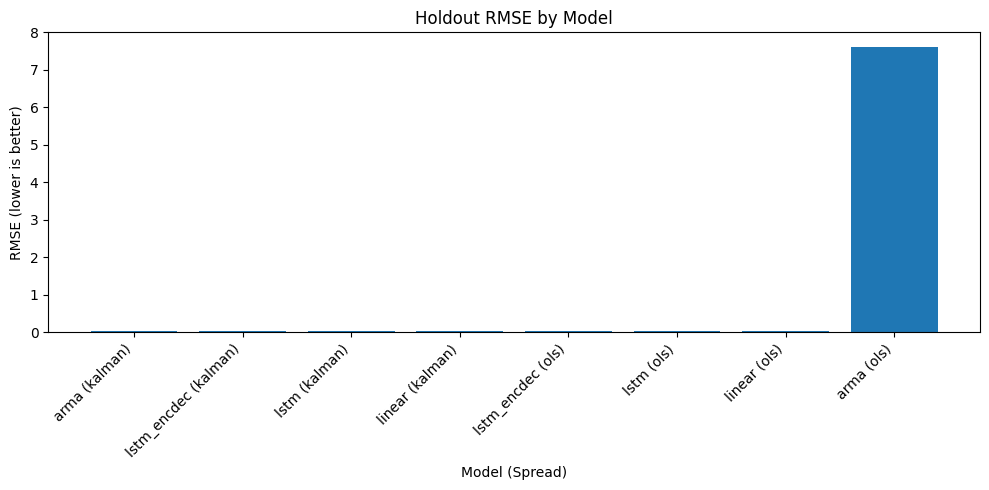

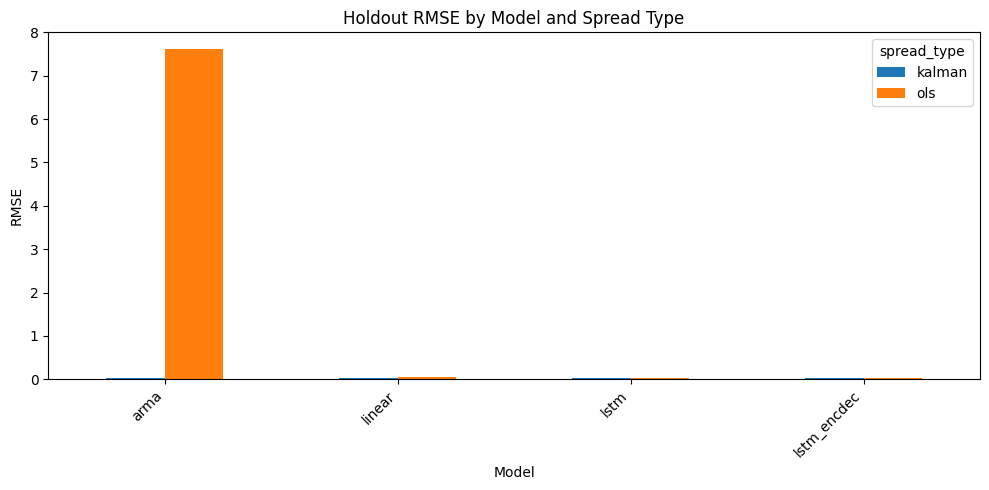

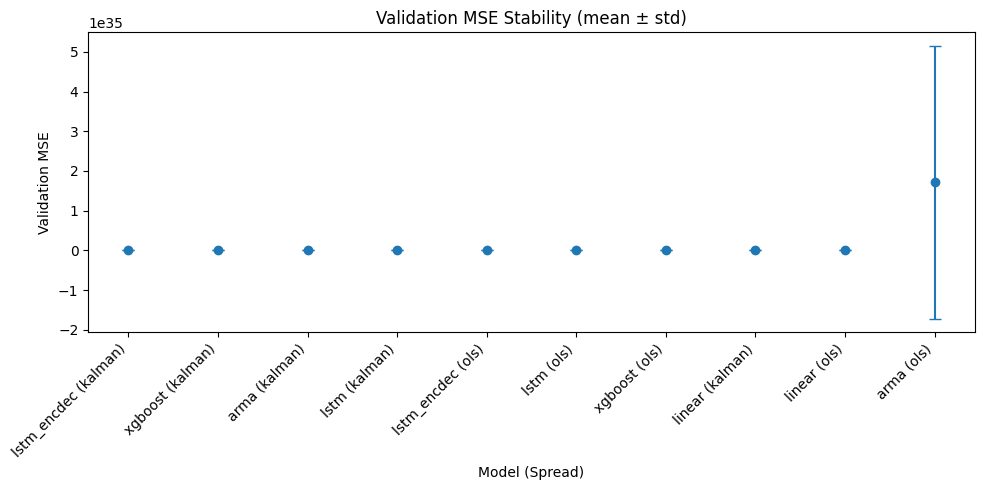

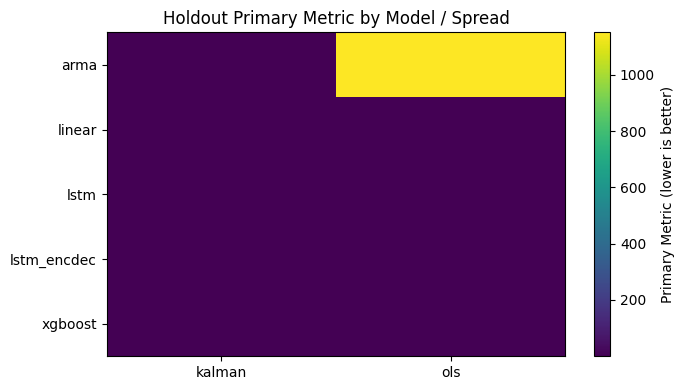

In [116]:
# 1) Bar chart of holdout RMSE by model (when RMSE exists)
holdout_rmse = (
    holdout_rows[holdout_rows['rmse'].notna()]
    .groupby(['model', 'spread_type'], as_index=False)['rmse']
    .mean()
    .sort_values('rmse')
)

if len(holdout_rmse):
    labels = holdout_rmse['model'] + ' (' + holdout_rmse['spread_type'] + ')'
    plt.figure(figsize=(10, 5))
    plt.bar(labels, holdout_rmse['rmse'])
    plt.title('Holdout RMSE by Model')
    plt.xlabel('Model (Spread)')
    plt.ylabel('RMSE (lower is better)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No holdout RMSE values available for bar chart.')

# 2) Grouped comparison by spread type
if len(holdout_rmse):
    pivot_rmse = holdout_rmse.pivot(index='model', columns='spread_type', values='rmse')
    ax = pivot_rmse.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Holdout RMSE by Model and Spread Type')
    ax.set_xlabel('Model')
    ax.set_ylabel('RMSE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 3) Validation error-bar plot (mean ± std) where available
val_plot = validation_stability.copy()
val_plot = val_plot[val_plot['avg_val_mse'].notna()].copy()
val_plot['std_val_mse'] = val_plot['std_val_mse'].fillna(0.0)
val_plot = val_plot.sort_values('avg_val_mse')

if len(val_plot):
    labels = val_plot['model'] + ' (' + val_plot['spread_type'] + ')'
    plt.figure(figsize=(10, 5))
    plt.errorbar(labels, val_plot['avg_val_mse'], yerr=val_plot['std_val_mse'], fmt='o', capsize=4)
    plt.title('Validation MSE Stability (mean ± std)')
    plt.xlabel('Model (Spread)')
    plt.ylabel('Validation MSE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No validation mean/std metrics available for error-bar plot.')

# 4) Optional heatmap-style view from holdout primary metric
heatmap_df = holdout_ranking.pivot(index='model', columns='spread_type', values='holdout_primary_metric')
if not heatmap_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(heatmap_df.values, aspect='auto')
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)
    ax.set_title('Holdout Primary Metric by Model / Spread')
    plt.colorbar(im, ax=ax, label='Primary Metric (lower is better)')
    plt.tight_layout()
    plt.show()

There appears to be a very suspicious value for ARMA OLS. We will proceed to investigate this model further.

In [117]:
df = pd.read_csv("../data/processed/arma_holdout_outputs/arma_ols/2014_2016/pairs/d_duk/arma_forecasts_test.csv")

# adjust column names if needed
y_true_col = "actual_value"
y_pred_col = "predicted_value"

df["abs_err"] = (df[y_true_col] - df[y_pred_col]).abs()
df["sq_err"] = (df[y_true_col] - df[y_pred_col]) ** 2

print(df[[y_true_col, y_pred_col, "abs_err", "sq_err"]]
      .sort_values("sq_err", ascending=False)
      .head(20))

print("max abs err:", df["abs_err"].max())
print("median abs err:", df["abs_err"].median())
print("mean abs err:", df["abs_err"].mean())

    actual_value  predicted_value      abs_err        sq_err
24      1.328746      2178.788486  2177.459740  4.741331e+06
80      1.341802         3.027661     1.685859  2.842122e+00
61      1.347944         2.972852     1.624908  2.640327e+00
49      1.347264        -0.256642     1.603906  2.572513e+00
85      1.352500         2.425725     1.073225  1.151813e+00
57      1.346908         2.344812     0.997904  9.958134e-01
76      1.347575         2.317800     0.970225  9.413356e-01
88      1.359951         2.301084     0.941134  8.857323e-01
79      1.342119         2.280911     0.938791  8.813290e-01
83      1.341949         2.190065     0.848116  7.193005e-01
82      1.335018         2.180942     0.845924  7.155870e-01
90      1.358429         2.193461     0.835032  6.972785e-01
54      1.352986         2.181802     0.828816  6.869354e-01
84      1.344423         2.155082     0.810660  6.571689e-01
89      1.361263         2.103834     0.742571  5.514117e-01
66      1.345627        

In [118]:
display(df.loc[[24]])
display(df.loc[20:28, ["actual_value", "predicted_value", "abs_err", "sq_err"]])
display(df["predicted_value"].describe())
display(df.sort_values("predicted_value", ascending=False).head(10))

,forecast_origin_date,target_date,current_spread,actual_value,predicted_value,actual_change,predicted_change,rolling_vol_20d_at_origin,predicted_z,pair,spread_col,p,q,horizon,eval_split,window_label,abs_err,sq_err
24,2017-02-07,2017-02-22,1.313891,1.328746,2178.788486,0.014854,2177.474595,0.011903,182936.054875,d|duk,spread_ols,9,8,10,test,2014_2016,2177.45974,4.741331e+06


,actual_value,predicted_value,abs_err,sq_err
20,1.315343,1.306920,0.008422,7.093584e-05
21,1.309191,1.573035,0.263845,6.961396e-02
22,1.320528,1.297075,0.023454,5.500721e-04
23,1.327549,1.256832,0.070716,5.000801e-03
24,1.328746,2178.788486,2177.459740,4.741331e+06
25,1.330615,1.307875,0.022740,5.171069e-04
26,1.332830,1.279937,0.052893,2.797654e-03
27,1.331975,1.339112,0.007136,5.092859e-05
28,1.336244,1.337984,0.001740,3.029315e-06


count     206.000000
mean       11.982719
std       151.705238
min        -0.256642
25%         1.327973
50%         1.333991
75%         1.348467
max      2178.788486
Name: predicted_value, dtype: float64

,forecast_origin_date,target_date,current_spread,actual_value,predicted_value,actual_change,predicted_change,rolling_vol_20d_at_origin,predicted_z,pair,spread_col,p,q,horizon,eval_split,window_label,abs_err,sq_err
24,2017-02-07,2017-02-22,1.313891,1.328746,2178.788486,0.014854,2177.474595,0.011903,182936.054875,d|duk,spread_ols,9,8,10,test,2014_2016,2177.459740,4.741331e+06
80,2017-05-01,2017-05-15,1.340910,1.341802,3.027661,0.000892,1.686751,0.003154,534.720663,d|duk,spread_ols,9,8,10,test,2014_2016,1.685859,2.842122e+00
61,2017-04-03,2017-04-18,1.349779,1.347944,2.972852,-0.001835,1.623073,0.004324,375.406981,d|duk,spread_ols,9,8,10,test,2014_2016,1.624908,2.640327e+00
85,2017-05-08,2017-05-22,1.354360,1.352500,2.425725,-0.001860,1.071365,0.003823,280.271831,d|duk,spread_ols,9,8,10,test,2014_2016,1.073225,1.151813e+00
57,2017-03-28,2017-04-11,1.348289,1.346908,2.344812,-0.001381,0.996523,0.005056,197.103404,d|duk,spread_ols,9,8,10,test,2014_2016,0.997904,9.958134e-01
76,2017-04-25,2017-05-09,1.345627,1.347575,2.317800,0.001948,0.972173,0.003140,309.563191,d|duk,spread_ols,9,8,10,test,2014_2016,0.970225,9.413356e-01
88,2017-05-11,2017-05-25,1.341925,1.359951,2.301084,0.018026,0.959160,0.004192,228.820771,d|duk,spread_ols,9,8,10,test,2014_2016,0.941134,8.857323e-01
79,2017-04-28,2017-05-12,1.343695,1.342119,2.280911,-0.001576,0.937215,0.003160,296.621133,d|duk,spread_ols,9,8,10,test,2014_2016,0.938791,8.813290e-01
90,2017-05-15,2017-05-30,1.341802,1.358429,2.193461,0.016627,0.851659,0.004075,208.971073,d|duk,spread_ols,9,8,10,test,2014_2016,0.835032,6.972785e-01
83,2017-05-04,2017-05-18,1.341296,1.341949,2.190065,0.000654,0.848770,0.003557,238.597008,d|duk,spread_ols,9,8,10,test,2014_2016,0.848116,7.193005e-01


Through looking deeper into the ARMA OLS model predictions, we can see that there is one specific predicted value that blows up the entire prediction out of proportion. ARMA can explode that badly because a multi-step forecast is generated recursively, so each predicted value feeds into the next step. If the fitted ARMA model is close to non-stationary or numerically unstable, even a small error at one forecast origin can get amplified very quickly over several steps. In this case, the selected ARMA(9,8) model is fairly high-order, which makes it more prone to overfitting and unstable coefficient estimates. As a result, one specific holdout origin likely produced an unstable fit, causing the 10-step forecast to blow up to an unrealistic value even though the rest of the predictions remained normal.

Therefore, for better visibility, visualizations of the model comparisons without ARMA OLS will be shown below.

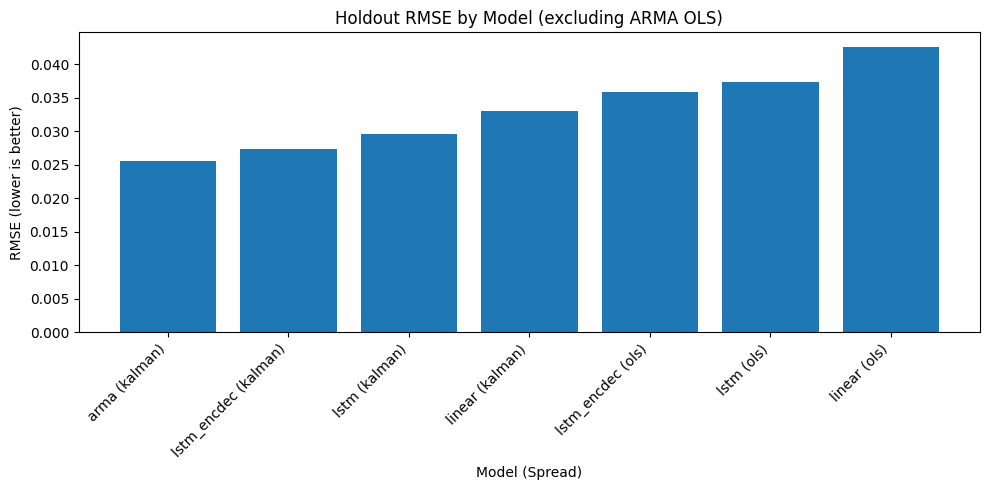

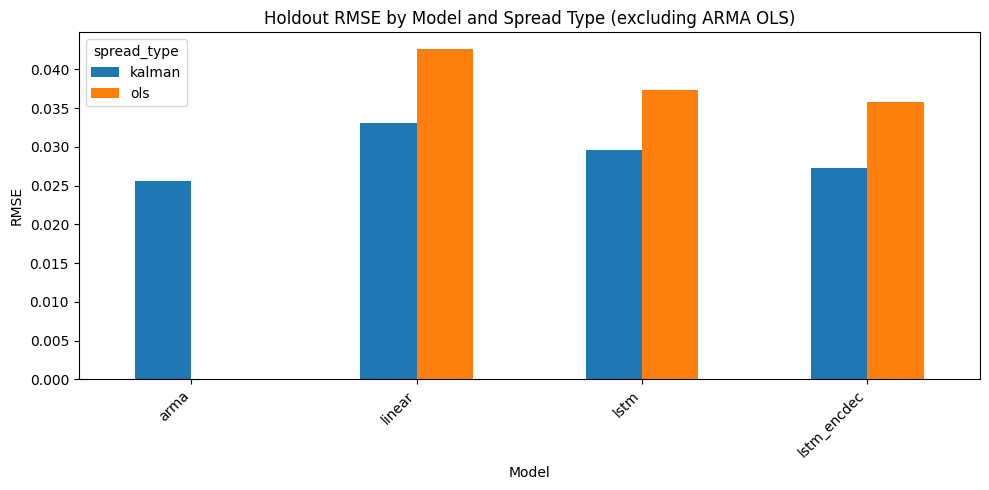

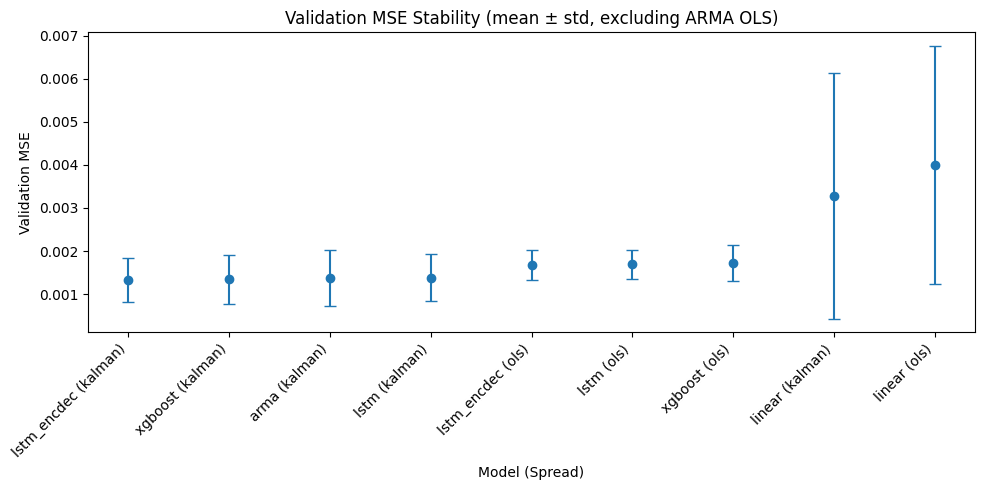

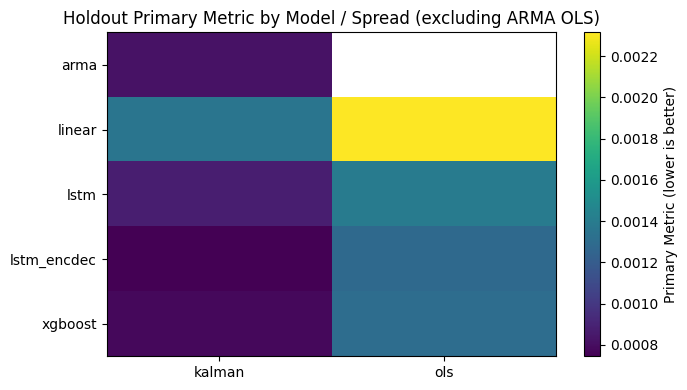

In [119]:
# Exclude ARMA OLS from plotting
holdout_rows_plot = holdout_rows[
    ~((holdout_rows['model'] == 'arma') & (holdout_rows['spread_type'] == 'ols'))
].copy()

holdout_ranking_plot = holdout_ranking[
    ~((holdout_ranking['model'] == 'arma') & (holdout_ranking['spread_type'] == 'ols'))
].copy()

validation_stability_plot = validation_stability[
    ~((validation_stability['model'] == 'arma') & (validation_stability['spread_type'] == 'ols'))
].copy()

plt.style.use('default')

# 1) Bar chart of holdout RMSE by model (when RMSE exists)
holdout_rmse = (
    holdout_rows_plot[holdout_rows_plot['rmse'].notna()]
    .groupby(['model', 'spread_type'], as_index=False)['rmse']
    .mean()
    .sort_values('rmse')
)

if len(holdout_rmse):
    labels = holdout_rmse['model'] + ' (' + holdout_rmse['spread_type'] + ')'
    plt.figure(figsize=(10, 5))
    plt.bar(labels, holdout_rmse['rmse'])
    plt.title('Holdout RMSE by Model (excluding ARMA OLS)')
    plt.xlabel('Model (Spread)')
    plt.ylabel('RMSE (lower is better)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No holdout RMSE values available for bar chart.')

# 2) Grouped comparison by spread type
if len(holdout_rmse):
    pivot_rmse = holdout_rmse.pivot(index='model', columns='spread_type', values='rmse')
    ax = pivot_rmse.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Holdout RMSE by Model and Spread Type (excluding ARMA OLS)')
    ax.set_xlabel('Model')
    ax.set_ylabel('RMSE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 3) Validation error-bar plot (mean ± std) where available
val_plot = validation_stability_plot.copy()
val_plot = val_plot[val_plot['avg_val_mse'].notna()].copy()
val_plot['std_val_mse'] = val_plot['std_val_mse'].fillna(0.0)
val_plot = val_plot.sort_values('avg_val_mse')

if len(val_plot):
    labels = val_plot['model'] + ' (' + val_plot['spread_type'] + ')'
    plt.figure(figsize=(10, 5))
    plt.errorbar(labels, val_plot['avg_val_mse'], yerr=val_plot['std_val_mse'], fmt='o', capsize=4)
    plt.title('Validation MSE Stability (mean ± std, excluding ARMA OLS)')
    plt.xlabel('Model (Spread)')
    plt.ylabel('Validation MSE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No validation mean/std metrics available for error-bar plot.')

# 4) Optional heatmap-style view from holdout primary metric
heatmap_df = holdout_ranking_plot.pivot(index='model', columns='spread_type', values='holdout_primary_metric')
if not heatmap_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(heatmap_df.values, aspect='auto')
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)
    ax.set_title('Holdout Primary Metric by Model / Spread (excluding ARMA OLS)')
    plt.colorbar(im, ax=ax, label='Primary Metric (lower is better)')
    plt.tight_layout()
    plt.show()

## 8. Short Interpretation

The code cell below generates concise observations from the consolidated tables.

In [125]:
print('Holdout comparison dataset:')
display(holdout_ranking)
print('Observations:')
if len(holdout_ranking):
    best_h = holdout_ranking.iloc[0]
    print(f"- Clean supervised error comparison now uses one aggregate row per model × spread × split; top holdout entry by MSE is {best_h['model']} ({best_h['spread_type']}) with holdout_mse_mean={best_h['holdout_mse_mean']:.6g}.")
else:
    print('- No holdout supervised ranking rows available.')
if len(validation_ranking):
    best_v = validation_ranking.iloc[0]
    print(f"- Validation ranking is also aggregated at the same grain; best validation entry is {best_v['model']} ({best_v['spread_type']}) with validation_mse_mean={best_v['validation_mse_mean']:.6g}.")
else:
    print('- No validation supervised ranking rows available.')
print('- OU is excluded because current OU artifacts are signal files, not supervised forecast-error metrics.')
print('- Tuning summaries are shown separately and are not part of final ranking tables.')
print('- Final model selection should prioritize cleaned holdout MSE, then be confirmed with backtest results.')


Holdout comparison dataset:


,model,spread_type,horizon,n_rows,holdout_mse_mean,holdout_mse_std,holdout_rank,metric_name,holdout_primary_metric,holdout_primary_metric_std,sample_metric_name
0,lstm_encdec,kalman,10.0,1,0.000745,NaN,1,mse_comparable,0.000745,NaN,mse_comparable
1,xgboost,kalman,10.0,5,0.000778,NaN,2,mse_comparable,0.000778,NaN,mse_comparable
2,arma,kalman,10.0,1,0.000821,NaN,3,mse_comparable,0.000821,NaN,mse_comparable
3,lstm,kalman,10.0,1,0.000878,NaN,4,mse_comparable,0.000878,NaN,mse_comparable
4,lstm_encdec,ols,10.0,1,0.001281,NaN,5,mse_comparable,0.001281,NaN,mse_comparable
5,xgboost,ols,10.0,5,0.001308,NaN,6,mse_comparable,0.001308,NaN,mse_comparable
6,linear,kalman,10.0,1,0.001355,NaN,7,mse_comparable,0.001355,NaN,mse_comparable
7,lstm,ols,10.0,1,0.001395,NaN,8,mse_comparable,0.001395,NaN,mse_comparable
8,linear,ols,10.0,1,0.002316,NaN,9,mse_comparable,0.002316,NaN,mse_comparable
9,arma,ols,10.0,1,1150.814782,NaN,10,mse_comparable,1150.814782,NaN,mse_comparable


Observations:
- Clean supervised error comparison now uses one aggregate row per model × spread × split; top holdout entry by MSE is lstm_encdec (kalman) with holdout_mse_mean=0.000744507.
- Validation ranking is also aggregated at the same grain; best validation entry is lstm_encdec (kalman) with validation_mse_mean=0.00132381.
- OU is excluded because current OU artifacts are signal files, not supervised forecast-error metrics.
- Tuning summaries are shown separately and are not part of final ranking tables.
- Final model selection should prioritize cleaned holdout MSE, then be confirmed with backtest results.


The consolidated model comparison shows a consistent pattern across both the holdout and validation results. Using the notebook’s primary ranking criterion of cleaned holdout MSE, the LSTM encoder-decoder with Kalman spread achieved the best holdout performance (MSE = 0.0007445), followed closely by XGBoost with Kalman spread (0.0007780), ARMA with Kalman spread (0.0008206), and LSTM with Kalman spread (0.0008782). The validation ranking supports the same ordering: LSTM encoder-decoder (Kalman) again performed best (mean validation MSE = 0.0013238), with XGBoost (Kalman) as a close second (0.0013393).

A second clear conclusion is that the Kalman-based spread consistently outperformed the OLS-based spread across all comparable supervised models. This suggests that the Kalman formulation provides a more stable and informative target for 10-day spread forecasting in this pipeline. In contrast, the linear regression variants were generally weaker than the best deep learning and tree-based models.

One important exception is ARMA with OLS spread, which produced an extreme forecast outlier and therefore an unrealistic error value. Inspection of the holdout forecasts shows one prediction exploding to approximately 2178.79 when the actual spread was only about 1.33, which inflated its holdout MSE to 1150.81. This behaviour is most likely due to recursive multi-step forecasting instability in a high-order ARMA specification, so this result should be treated as a numerical failure rather than as a meaningful indication of model quality.

## 9. Final Conclusion

Overall, the notebook results indicate that the LSTM encoder-decoder using the Kalman spread is the strongest supervised forecasting model in the current experiment setting. It ranked first on both holdout and validation MSE, making it the most credible candidate under the notebook’s model-selection rule of prioritizing holdout performance and using validation as a secondary robustness check. XGBoost with Kalman spread is a very close runner-up and serves as an especially strong benchmark because its performance is nearly as good while remaining simpler and more interpretable than the sequence models.

More broadly, the results suggest that spread construction matters as much as model choice: Kalman-based spreads consistently led to lower prediction error than OLS-based spreads. This means the best-performing models were not only better architectures, but also benefited from a better target representation. Meanwhile, ARMA with Kalman spread remains useful as a traditional baseline, but the OLS-based ARMA variant should not be relied upon unless its instability is addressed. The OU model is excluded from this comparison because its current outputs are trading signal artifacts rather than directly comparable supervised forecast-error metrics.

Therefore, the main conclusion from this notebook is that Kalman-based supervised forecasting models should be prioritized for the next stage of evaluation, with LSTM encoder-decoder (Kalman) as the leading candidate and XGBoost (Kalman) as the most competitive alternative. However, the final model choice should still be confirmed through backtesting and trading performance, since the lowest forecast error does not automatically translate into the highest profitability.